# Three-point functions of operators with spin on the cylinder

This notebook analyses the three-point structure constants computed by the C++ program and compares it to the analytic prediction

$$
\begin{align}
\boxed{C^\text{ref}_{(r_1,s_1)(r_2,s_2)(r_3,s_3)} =\prod_{\epsilon_1,\epsilon_2,\epsilon_3=\pm} \Gamma_\beta^{-1} \left(\tfrac{\beta+\beta^{-1}}{2} + \tfrac{\beta}{2}\left|\textstyle{\sum_i} \epsilon_ir_i\right| + \tfrac{\beta^{-1}}{2}\textstyle{\sum_i} \epsilon_is_i\right)}\ .
\end{align}
$$

We will use the short notation $C_{123} = C^{\text{ref}}_{(r_1,s_1)(r_2,s_2)(r_3,s_3)}$, and let an index $0$ denote an insertion of the identity operator which in our conventions has indices $(0, 2\beta P_{(1, 1)})$.

The quantity we want to compute with the lattice prediction is the ratio

$$
\omega_{123} = \frac{C_{123} \sqrt{C_{000}}}{\sqrt{C_{101}C_{202}C_{303}}}
$$

## CFT prediction

In [4]:
using BarnesDoubleGamma,
    JuliVirBootstrap,
    Plots,
    JLD2,
    LaTeXStrings,
    DelimitedFiles

import Polynomials.fit,
    LinearAlgebra.dot,
    IterTools.product

# get to the results directory
cd("../results")

In [5]:
function Cref(c::CentralCharge, ri, si)
    β = abs(c.β)
    return prod(
        inv(doublegamma(
            (β+inv(β))/2 + β/2*abs(dot(e, ri)) + inv(β)/2*dot(e, si),
            β,
            1e-16
        ))
        for e in product((-1, 1), (-1, 1), (-1, 1))
    )
end

P11(c) = ConformalDimension(c, :Δ, 0).P

function omega(c::CentralCharge, ri, si)
    β = abs(c.β)
    C123 = Cref(c, ri, si)
    C101 = Cref(c, (ri[1], 0, ri[1]), (si[1], 2*β*P11(c), si[1]))
    C202 = Cref(c, (ri[2], 0, ri[2]), (si[2], 2*β*P11(c), si[2]))
    C303 = Cref(c, (ri[3], 0, ri[3]), (si[3], 2*β*P11(c), si[3]))
    C220 = Cref(c, (ri[2], ri[2], 0), (si[2], si[2], 2*β*P11(c)))
    C000 = Cref(c, (0, 0, 0), (2*β*P11(c), 2*β*P11(c), 2*β*P11(c)))

    C123*sqrt(C000/C101/C303/C202)
end

omega(c, i1, i2, i3) = omega(c, (i1[1], i2[1], i3[1]), (i1[2], i2[2], i3[2]))
omega101010(c::CentralCharge) = omega(c, (1, 0), (1, 0), (1, 0))
omega101010(β) = omega101010(CentralCharge(:β, β))

# check that the value is right for percolation
println(isapprox(omega101010(sqrt(2/3)), 0.9523590967841016697715))

true


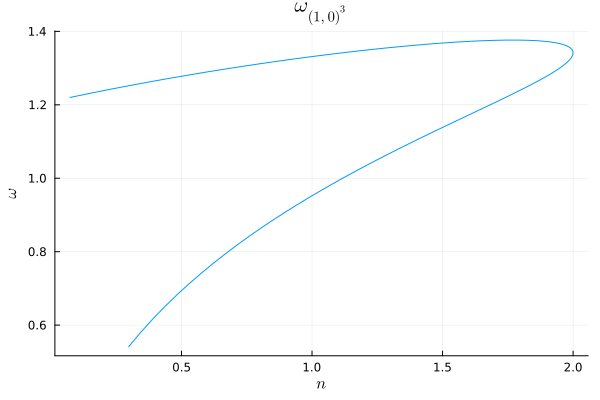

In [6]:
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
omegas = real.([omega(c, (1, 0), (1, 0), (1, 0)) for c in cs])

plot(ns, omegas, xlabel = L"n", ylabel = L"ω", title=L"ω_{(1, 0)^3}", label=nothing)

## Lattice results

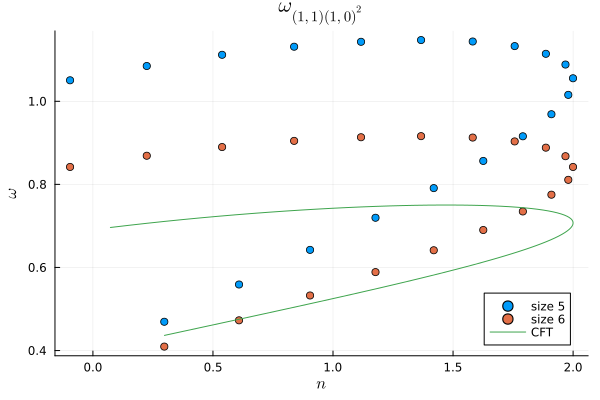

In [9]:
output_dict = load("3pt_11_10_10.jld2", "data")
output(L) = readdlm(IOBuffer(output_dict[L]), '\t')
ns = output(5)[2:end, 2]
ω_lattice(L) = .- output(L)[2:end, 3]

plt = plot(xlabel = L"n", ylabel = L"ω", title=L"ω_{(1, 1)(1, 0)^2}")
for L in 5:6
    scatter!(ns, ω_lattice(L), label="size $L")
end

cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(c, (1, 1), (1, 0), (1, 0)) for c in cs])

plot!(ns, ω_CFT ./ sqrt(2), label="CFT")
savefig("exported_figures/omega111010.png")
display(plt)